# CREMA-D Model Explorer

Load, visualize, and compare previously trained CREMA-D experiments using the metrics saved on Google Drive. All plots reuse `src/plot_functions.py` so they stay consistent with other notebooks.

This notebook discovers every experiment run under `MyDrive/CREMAD/Models`, summarizes available metrics/hyperparameters, and lets you select one or more runs to visualize. It is designed for Google Colab and assumes `metrics.json` and `hyperparameters.json` exist inside each run directory.

In [ ]:
import os
import sys
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")

BASE_DIR = Path("/content/drive/MyDrive/CREMAD/Models")
REPO_DIR = Path("/content/qnn-transfer-learning")

if IN_COLAB and not os.path.isdir(REPO_DIR):
    %cd /content
    !git clone https://github.com/lburdman/qnn-transfer-learning.git

%cd qnn-transfer-learning

SRC_DIR = REPO_DIR / "src"
COMPARISON_DIR = BASE_DIR / "comparisons"

if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))
elif not SRC_DIR.exists():
    print(f"Warning: SRC_DIR not found at {SRC_DIR}. Update the path if needed.")

from plot_functions import (
    build_summary_dataframe,
    select_runs,
    plot_training_for_run,
    plot_comparison_across_runs,
)

print(f"BASE_DIR: {BASE_DIR}")
print(f"SRC_DIR: {SRC_DIR}")


## Discover and summarize experiments

In [18]:
summary_df = build_summary_dataframe(BASE_DIR)
summary_df

,model_family,variant,run_name,full_path,base_model,batch_size,classical_model,data_root,embedding_dir,learning_rate,mfcc_dir,model_dir,n_qubits,num_epochs,q_depth,quantum
0,cnn_mfcc,cnn_mfcc_classic,cnn_mfcc_classic,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,cnn_mfcc,8,512_nq_2,/content/drive/MyDrive/CREMAD,/content/drive/MyDrive/CREMAD/Embeddings,0.0001,/content/drive/MyDrive/CREMAD/MFCC,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,6,20,3,False
1,cnn_mfcc,cnn_mfcc_classic,run_12-03_20-36-03,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,cnn_mfcc,8,512_nq_2,/content/drive/MyDrive/CREMAD,/content/drive/MyDrive/CREMAD/Embeddings,0.0004,/content/drive/MyDrive/CREMAD/MFCC,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,6,20,3,False
2,cnn_mfcc,cnn_mfcc_quantum,cnn_mfcc_quantum_bi,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,cnn_mfcc,8,512_nq_2,/content/drive/MyDrive/CREMAD,/content/drive/MyDrive/CREMAD/Embeddings,0.0003,/content/drive/MyDrive/CREMAD/MFCC,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,6,20,3,True
3,cnn_mfcc,cnn_mfcc_quantum,run_12-02_22-37-18,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,cnn_mfcc,8,512_nq_2,/content/drive/MyDrive/CREMAD,/content/drive/MyDrive/CREMAD/Embeddings,0.0004,/content/drive/MyDrive/CREMAD/MFCC,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,6,20,3,True
4,cnn_mfcc,cnn_mfcc_quantum,run_12-03_22-26-09,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,cnn_mfcc,8,512_nq_2,/content/drive/MyDrive/CREMAD,/content/drive/MyDrive/CREMAD/Embeddings,0.0001,/content/drive/MyDrive/CREMAD/MFCC,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,6,20,3,True
5,cnn_mfcc,cnn_mfcc_quantum,run_12-04_01-14-08,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,cnn_mfcc,8,512_nq_2,/content/drive/MyDrive/CREMAD,/content/drive/MyDrive/CREMAD/Embeddings,0.0001,/content/drive/MyDrive/CREMAD/MFCC,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,6,20,3,True
6,cnn_mfcc,cnn_mfcc_quantum,run_12-04_19-36-41,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,cnn_mfcc,8,512_nq_2,/content/drive/MyDrive/CREMAD,/content/drive/MyDrive/CREMAD/Embeddings,0.0001,/content/drive/MyDrive/CREMAD/MFCC,/content/drive/MyDrive/CREMAD/Models/cnn_mfcc/...,8,25,3,True
7,cnn_specs,cnn_specs_classic,cnn_specs_classic_bi,/content/drive/MyDrive/CREMAD/Models/cnn_specs...,cnn_specs,8,512_nq_2,/content/drive/MyDrive/CREMAD,/content/drive/MyDrive/CREMAD/Embeddings,0.0004,/content/drive/MyDrive/CREMAD/MFCC,/content/drive/MyDrive/CREMAD/Models/cnn_specs...,10,20,2,False
8,cnn_specs,cnn_specs_classic,cnn_specs_classic_tri,/content/drive/MyDrive/CREMAD/Models/cnn_specs...,cnn_specs,8,512_nq_2,/content/drive/MyDrive/CREMAD,/content/drive/MyDrive/CREMAD/Embeddings,0.0001,/content/drive/MyDrive/CREMAD/MFCC,/content/drive/MyDrive/CREMAD/Models/cnn_specs...,8,25,3,False
9,cnn_specs,cnn_specs_quantum,cnn_specs_quantum_bi,/content/drive/MyDrive/CREMAD/Models/cnn_specs...,cnn_specs,8,512_nq_2,/content/drive/MyDrive/CREMAD,/content/drive/MyDrive/CREMAD/Embeddings,0.0004,/content/drive/MyDrive/CREMAD/MFCC,/content/drive/MyDrive/CREMAD/Models/cnn_specs...,10,20,2,True


## Select models to analyze

Pick runs by index (from the summary table) or by `run_name`. Update `SELECTED_RUN_INDICES` or `SELECTED_RUN_NAMES` as needed.

In [19]:
SELECTED_RUN_INDICES = [7,9]  # e.g., [0, 2]
SELECTED_RUN_NAMES = []  # e.g., ["2023-11-01_12-00-00"] ["12-04_15-51-56", "12-04_15-26-47"]

selected_runs = select_runs(summary_df, indices=SELECTED_RUN_INDICES, run_names=SELECTED_RUN_NAMES)
print(f"Selected {len(selected_runs)} run(s).")
selected_runs

Selected 2 run(s).


[{'model_family': 'cnn_specs',
  'variant': 'cnn_specs_classic',
  'run_name': 'cnn_specs_classic_bi',
  'full_path': '/content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_classic/cnn_specs_classic_bi',
  'base_model': 'cnn_specs',
  'batch_size': 8,
  'classical_model': '512_nq_2',
  'data_root': '/content/drive/MyDrive/CREMAD',
  'embedding_dir': '/content/drive/MyDrive/CREMAD/Embeddings',
  'learning_rate': 0.0004,
  'mfcc_dir': '/content/drive/MyDrive/CREMAD/MFCC',
  'model_dir': '/content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_classic/run_12-04_15-51-56',
  'n_qubits': 10,
  'num_epochs': 20,
  'q_depth': 2,
  'quantum': False},
 {'model_family': 'cnn_specs',
  'variant': 'cnn_specs_quantum',
  'run_name': 'cnn_specs_quantum_bi',
  'full_path': '/content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_quantum/cnn_specs_quantum_bi',
  'base_model': 'cnn_specs',
  'batch_size': 8,
  'classical_model': '512_nq_2',
  'data_root': '/content/drive/MyDrive/CREMAD',
  'embedd

## Plot training evolution for each model

Plots use `plot_overlapped_metrics` from `plot_functions.py` and are also saved inside each run folder as `training_overview.png`.

Figure saved to: /content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_classic/cnn_specs_classic_bi/training_overview.png

Model statistics for cnn_specs_classic_bi:
  Epochs trained: 20
  Best Test Accuracy (from log): 0.9705
  Best Test/Val Loss (calculated): 0.0995
Figure saved to: /content/drive/MyDrive/CREMAD/Models/cnn_specs/cnn_specs_quantum/cnn_specs_quantum_bi/training_overview.png

Model statistics for cnn_specs_quantum_bi:
  Epochs trained: 20
  Best Test Accuracy (from log): 0.9626
  Best Test/Val Loss (calculated): 0.1103


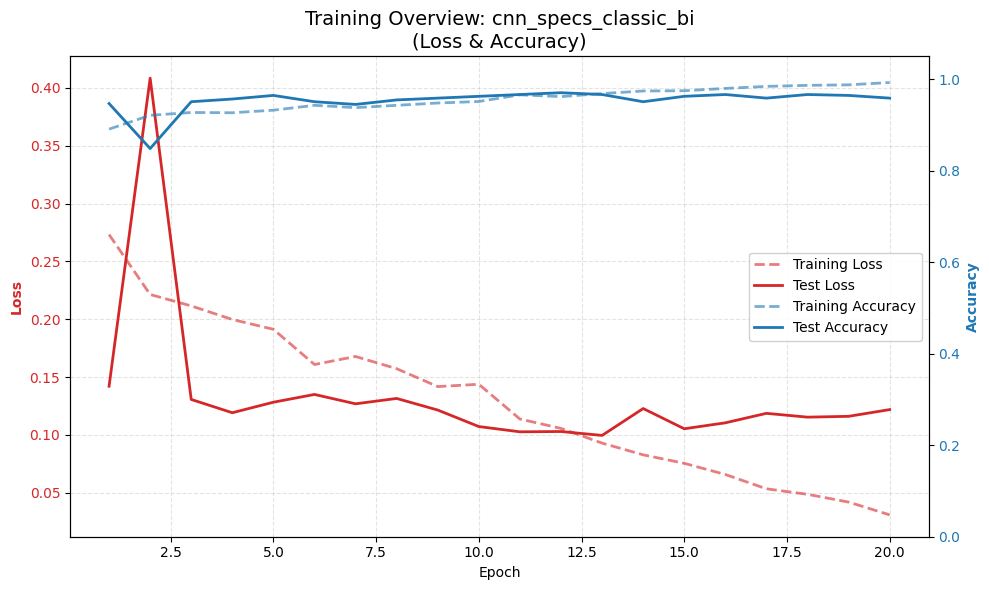

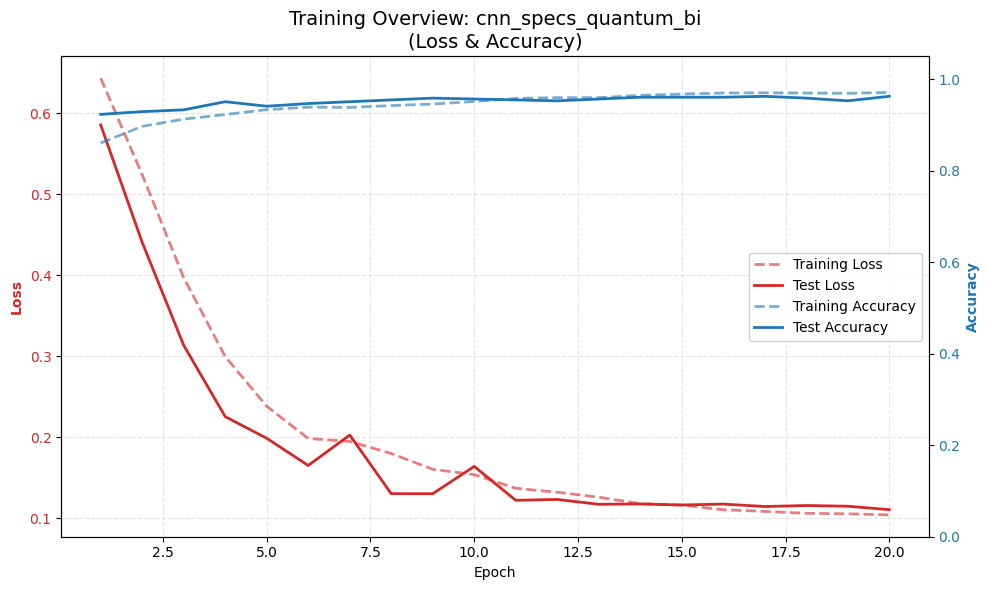

In [20]:
for run in selected_runs:
    plot_training_for_run(run)

## Cross-model comparison

Generates comparison plots (line + bar) for the selected runs and stores them under `BASE_DIR / "comparisons"`.

In [ ]:
plot_comparison_across_runs(
    selected_runs,
    task_name="ANG - SAD - HAP",
    comparison_dir=COMPARISON_DIR,
)
